In [131]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from astropy.coordinates import AltAz, EarthLocation, SkyCoord
from astropy.time import Time
from tqdm import tqdm
import os
from itertools import groupby
import json
import scipy

# **I. Elevations of X-band Targets**

In [2]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/all_xband_info.csv')
info

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP62637,AGBT23B_999_14,60291_31980,192.5380,19.8676,300.540925,82.733377,96.254146,86.314790,1.660433e+08,1.202716e+15,3.237142e+08,1.860099e+15,1.442647e+08,9.590752e+14,3.834180e+07,7.402785e+13
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
2,HIP116538,AGBT20B_999_49,59203_03185,354.3079,57.9490,113.193170,-3.512770,23.443145,113.147054,1.279805e+08,7.541369e+14,2.869724e+08,1.465254e+15,1.107629e+08,6.130784e+14,2.865754e+07,4.469731e+13
3,HIP96264,AGBT20B_999_49,59203_36476,293.5826,71.6109,103.349354,22.362166,25.866928,102.328982,1.403981e+08,8.868837e+14,3.001235e+08,1.599971e+15,1.218205e+08,7.177445e+14,3.177227e+07,5.320469e+13
4,HIP53862,AGBT20A_999_44,59023_07533,165.2817,-5.7016,259.734245,47.703048,131.467876,96.888255,1.479999e+08,9.745009e+14,3.075883e+08,1.679683e+15,1.285353e+08,7.858121e+14,3.370077e+07,5.890246e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,HIP6529,AGBT20B_996_01,59225_75932,20.9600,25.9246,131.988102,-36.376712,53.241482,122.589484,1.195448e+08,6.710386e+14,2.772991e+08,1.370729e+15,1.032019e+08,5.466822e+14,2.656755e+07,3.945346e+13
4995,HIP5701,AGBT20B_996_01,59225_76780,18.3398,25.4659,129.141570,-37.141396,51.810902,120.211314,1.214849e+08,6.896553e+14,2.795800e+08,1.392673e+15,1.049437e+08,5.616120e+14,2.704631e+07,4.062254e+13
4996,HIP5777,AGBT20B_996_01,59225_78072,18.5185,25.8356,129.291960,-36.756451,51.679375,120.488749,1.212525e+08,6.874098e+14,2.793086e+08,1.390051e+15,1.047351e+08,5.598128e+14,2.698890e+07,4.048135e+13
4997,HIP5965,AGBT20B_996_01,59225_77421,19.1727,24.5039,130.227874,-38.009838,53.018922,120.587397,1.211702e+08,6.866161e+14,2.792124e+08,1.389122e+15,1.046613e+08,5.591768e+14,2.696859e+07,4.043146e+13


In [3]:
def convert_to_mjd(time):
    day, seconds = time.split('_')
    return int(day) + int(seconds) / 86400

  0%|          | 0/4999 [00:00<?, ?it/s]

100%|██████████| 4999/4999 [00:27<00:00, 182.01it/s]


(array([  17.,    6.,    7.,    4.,  358., 1876., 1051.,  910.,  590.,
         180.]),
 array([-50.73529875, -36.83692448, -22.93855022,  -9.04017595,
          4.85819831,  18.75657258,  32.65494684,  46.55332111,
         60.45169537,  74.35006964,  88.2484439 ]),
 <BarContainer object of 10 artists>)

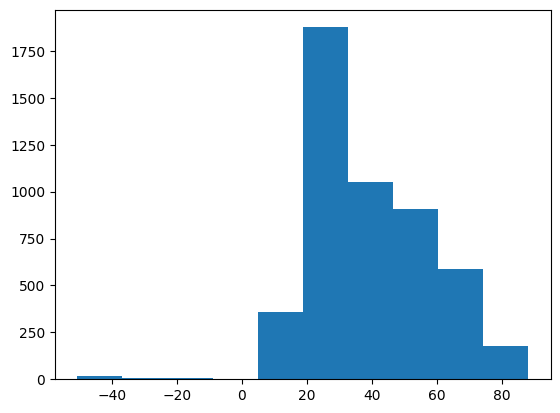

In [4]:
gbt = EarthLocation.of_site('GBT')

def get_elevation(targ):
    i = info[info['source'] == targ].index[0]
    ra, dec = info.at[i, 'ra'], info.at[i, 'dec']
    mjd = convert_to_mjd(info.at[i, 'time'])

    coords = SkyCoord(ra, dec, frame='icrs', unit='deg')
    time = Time(mjd, format='mjd', scale='utc')
    alt = coords.transform_to(AltAz(obstime=time, location=gbt)).alt.value
    
    return alt

alts = list(tqdm(map(get_elevation, info['source']), total=len(info['source'])))
plt.hist(alts)


In [5]:
sum([alt < 0 for alt in alts])

32

## Calibrated spectra colored by elevation

  1%|          | 18/1927 [00:00<00:10, 179.30it/s]

100%|██████████| 1927/1927 [00:10<00:00, 189.94it/s]


(0.0, 50.0)

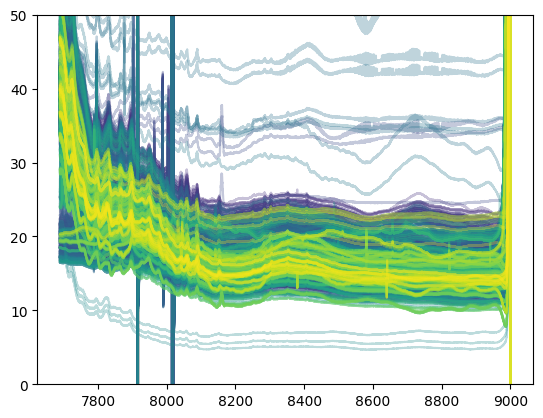

In [8]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/0'

names = [file.split('.')[0] for file in os.listdir(data_dir)]
alts = np.array(list(tqdm(map(get_elevation, names), total=len(names))))
indices = np.argsort(alts)
alts = alts[indices]
names = np.array(names)[indices]
cmap = mpl.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=min(alts), vmax=max(alts))

for name, alt in zip(names, alts):
    data = np.load(os.path.join(data_dir, name + '.npy'))
    plt.plot(*data, color=cmap(norm(alt)), alpha=0.3)

plt.ylim(0,50)

(0.0, 25.0)

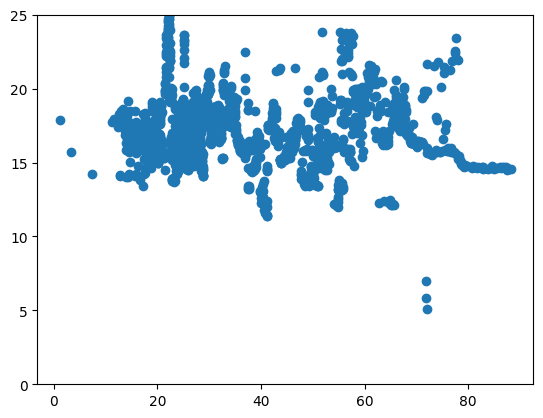

In [9]:
def sample_spec(name, freq):
    spec = np.load(os.path.join(data_dir, name))
    return spec[1][np.argmin(np.abs(spec[0]-freq))]

pts = [sample_spec(name, 8400) for name in os.listdir(data_dir)]
plt.scatter(alts, pts)
plt.ylim(0, 25)

No trend...

### What about the SEFDs

In [10]:
table = pd.read_table('/home/bhanselman/x_0002_sed.out', delimiter='|').dropna()
unspliced_table = table[table.iloc[:, 8] == 64]
locs = unspliced_table.iloc[:,6].tolist()
locs = [loc.replace(' ', '') for loc in locs]

epochs = list(set(info['epoch']))

def convert_to_seconds(l):
    mjd, seconds = l.split('_')
    mjd, seconds = int(mjd), int(seconds)
    return mjd * 86400 + seconds

def get_epoch(l):
    return l.split('/')[3]

def epoch_sort_key(l):
    return l.split('/')[3], convert_to_seconds('_'.join(l.split('_')[-4:-2]))

def get_mjd_and_time_seconds(l):
    return '_'.join(l.split('_')[-4:-2])

/tmp/ipykernel_3303987/366484729.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_table('/home/bhanselman/x_0002_sed.out', delimiter='|').dropna()


In [11]:
calibrator_locs = [loc for loc in locs if '_3C' in loc and get_epoch(loc) in epochs]
calibrator_locs_sorted = {
    epoch: list(files)
    for epoch, files in groupby(sorted(calibrator_locs, key=epoch_sort_key), key=get_epoch)}
def group_by_cadence(files): 
    # Remove files without 'blp' - need for splicing
    # files = [f for f in files if 'blp' in f]

    times = sorted(list(set(get_mjd_and_time_seconds(f) for f in files)), key=convert_to_seconds)
    time_vals = [convert_to_seconds(t) for t in times]

    cadences = []
    current_cadence = [times[0]]
    for i in range(len(times)-1):
        diff = int(time_vals[i+1]) - int(time_vals[i])
        if 100 < diff < 140:
            current_cadence.append(times[i+1])
        else:
            cadences.append(current_cadence)
            current_cadence = [times[i+1]]
    cadences.append(current_cadence)
    # Only keep cadences with 3 scans - save just the ON and OFF scans
    if any(len(cadence) > 3 for cadence in cadences):
        print('Warning: Some cadences have more than 3 scans')
    cadences = [cadence for cadence in cadences if len(cadence) >= 3]
    # Create dictionary to store cadences and corresponding files
    # 1/19/26 - doing just the first cadence found, but this might change.
    if len(cadences):
        cadences_dict = {
            'ON': [f for f in files if get_mjd_and_time_seconds(f) == cadences[0][0]],
            'OFF': [f for f in files if get_mjd_and_time_seconds(f) == cadences[0][1]],
        }
        return cadences_dict
    else:
        return None

cadence_group = {
    target: group_by_cadence(files)
    for target, files in calibrator_locs_sorted.items()
    if group_by_cadence(files)
}

In [12]:
time_lookup = {
    epoch: convert_to_seconds(get_mjd_and_time_seconds(epoch_dict['ON'][0]))
    for epoch, epoch_dict in cadence_group.items()
}
lookup_save_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/time_lookup.json'
with open(lookup_save_path, 'w') as json_file:
    json.dump(time_lookup, json_file, indent=4)

In [13]:
cal_lookup = {
    epoch: epoch_dict['ON'][0].split('_')[-2]
    for epoch, epoch_dict in cadence_group.items()
}
lookup_save_path = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/cal_lookup.json'
with open(lookup_save_path, 'w') as json_file:
    json.dump(cal_lookup, json_file, indent=4)

In [14]:
with open('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/time_lookup.json', 'r') as file:
    time_lookup = json.load(file)

with open('/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/cal_lookup.json', 'r') as file:
    cal_lookup = json.load(file)

def get_elevation_calibrator(epoch):
    name = cal_lookup[epoch]
    mjd = time_lookup[epoch] / 86400
    coords = SkyCoord.from_name('M16')
    time = Time(mjd, format='mjd', scale='utc')
    alt = coords.transform_to(AltAz(obstime=time, location=gbt)).alt.value
    return alt

100%|██████████| 45/45 [00:00<00:00, 129.28it/s]


(0.0, 50.0)

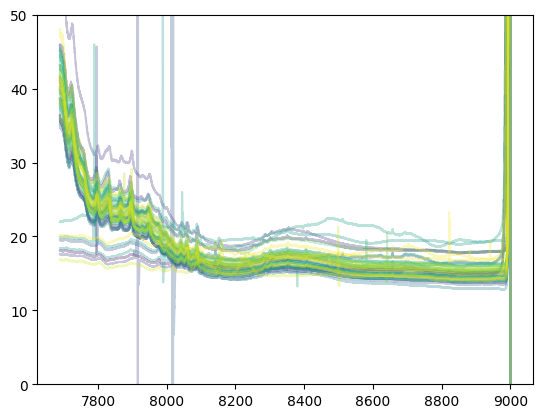

In [19]:
cal_dir = '/home/dataadmin/GBTData/SharedDataDirectory/calibrator_spectra_v2/0'

epochs = os.listdir(cal_dir)
alts = np.array(list(tqdm(map(get_elevation_calibrator, epochs), total=len(epochs))))
indices = np.argsort(alts)
alts = alts[indices]
epochs = np.array(epochs)[indices]
cmap = mpl.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=min(alts), vmax=max(alts))

for epoch, alt in zip(epochs, alts):
    off = np.load(os.path.join(cal_dir, epoch, 'OFF.npy'))
    gain = np.load(os.path.join(cal_dir, epoch, 'gain.npy'))
    data = np.array([off[0], off[1] / gain[1]])
    plt.plot(*data, color=cmap(norm(alt)), alpha=0.3)

plt.ylim(0, 50)

# **II. Normalization via Gaussian Process**

## Test

In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, ExpSineSquared, WhiteKernel

(0.0, 30.0)

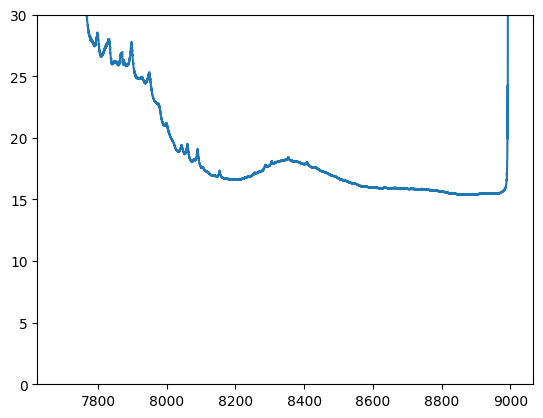

In [3]:
data = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/calibrated/0/HIP3.npy')
plt.plot(*data)
plt.ylim(0,30)

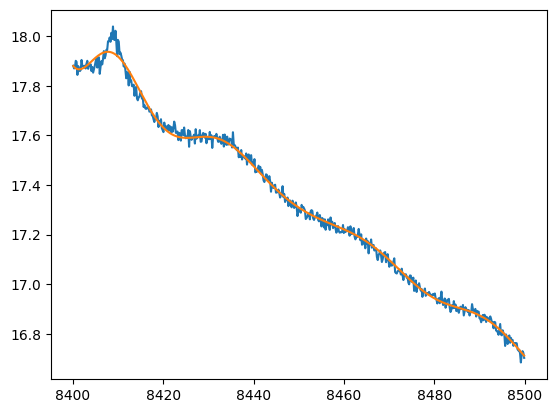

In [63]:
slice = data[:, np.argmin(np.abs(data[0]-8400)):np.argmin(np.abs(data[0]-8500))]
x_train = slice[0, ::4].reshape(-1, 1)
y_train = slice[1, ::4]
# x_train = slice[0].reshape(-1, 1)
# y_train = slice[1]
kernel = (
    1.0 * RBF(length_scale=50.0) +
    #1.0 * ExpSineSquared(length_scale=50.0, periodicity=20, periodicity_bounds=(1, 40)) + 
    1.0 * WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1))
)
# long_term_trend_kernel = 50.0**2 * RBF(length_scale=50.0)
# seasonal_kernel = (
#     2.0**2
#     * RBF(length_scale=100.0)
#     * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
# )
# noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(
#     noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5)
# )
# kernel = long_term_trend_kernel + seasonal_kernel + noise_kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gp.fit(x_train, y_train)
x_test = slice[0].reshape(-1, 1)
mean = gp.predict(x_test)
plt.plot(*slice)
plt.plot(x_test.ravel(), mean)

## With blanking

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False False False False False False False False False False
 False False False False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


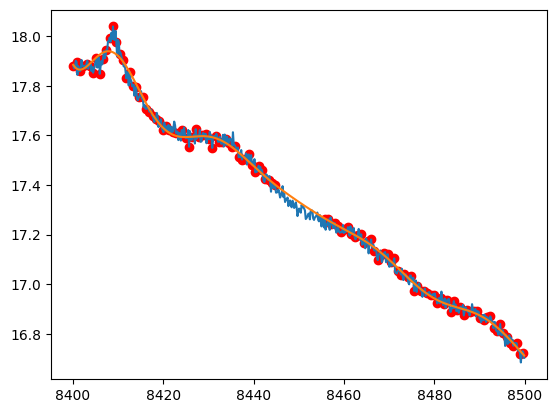

In [65]:
x_train = slice[0, ::4]
y_train = slice[1, ::4]
mask = (x_train < 8445) | (x_train > 8455)
print(mask)
x_train = x_train[mask].reshape(-1, 1)
y_train = y_train[mask]
kernel = (
    1.0 * RBF(length_scale=50.0) +
    #1.0 * ExpSineSquared(length_scale=50.0, periodicity=20, periodicity_bounds=(1, 40)) + 
    1.0 * WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1))
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gp.fit(x_train, y_train)
x_test = slice[0].reshape(-1, 1)
mean = gp.predict(x_test)
plt.plot(*slice)
plt.plot(x_test.ravel(), mean)
plt.scatter(x_train, y_train, c='r')

Not looking too promising...

## Normalization attempt

In [87]:
def normalize_gp(data, freqs=None, inner=10, outer=70):
    if freqs is None:
        freqs = (8400, 8500)
    xs, ys = data
    xs_trimmed = data[0, np.argmin(np.abs(data[0]-freqs[0])):np.argmin(np.abs(data[0]-freqs[1]))]
    normalized_spectrum = []
    for x in tqdm(xs_trimmed):
        i = xs.tolist().index(x)
        x_train = xs[i%4::4]
        y_train = ys[i%4::4]
        mask = ((x_train > x - outer) & (x_train < x - inner)) | ((x_train > x + inner) & (x_train < x + outer))
        x_train = x_train[mask].reshape(-1, 1)
        y_train = y_train[mask]
        kernel = (
            1.0 * RBF(length_scale=50.0) +
            #1.0 * ExpSineSquared(length_scale=50.0, periodicity=20, periodicity_bounds=(1, 40)) + 
            1.0 * WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1))
        )
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
        gp.fit(x_train, y_train)
        mean = gp.predict(x.reshape(1, -1))[0]
        normalized_spectrum.append(ys[i] - mean)
    print(normalized_spectrum)
    return np.array([xs_trimmed, normalized_spectrum])

  4%|▍         | 13/327 [00:13<06:01,  1.15s/it]/opt/conda/envs/hyper/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
  8%|▊         | 27/327 [00:28<05:35,  1.12s/it]/opt/conda/envs/hyper/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
 17%|█▋        | 55/327 [00:58<03:57,  1.15it/s]/opt/conda/envs/hyper/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge 

[-0.15554163198205728, -0.14934437507720588, -0.13258859147241253, 0.033946831356054474, -0.11371061145967332, -0.15309321221337768, -0.09246869770151633, 0.2566411809562936, 0.00807068201339689, -0.12238423659609055, -0.06245728527103367, 0.037486417518920234, -0.12636076597663148, -0.0868652117541302, -0.0495056004243537, -0.10544195785340449, -0.08509003123259262, -0.037265091630342084, -0.031565759029696494, 0.04035527512121462, -0.08780393033701372, -0.03749669126842292, 0.03680831514429883, 0.0600942086848022, 0.04271756427521467, -0.046802660835211896, 0.06217267859159392, -0.03555173970260839, -0.007462411899695098, -0.012505418457656958, 0.03340198979366349, 0.09486654307261588, -0.05223834186599774, 0.01193465382251091, 0.04360879135856166, -0.0023832476341993925, 0.1139472847438121, 0.1012527901023823, 0.07030432300235745, 0.06641593854766015, 0.09436091898078658, 0.1582096498311465, 0.16888085817305765, 0.13436364111527155, 0.16330487542485983, 0.17046728752543672, 0.198935

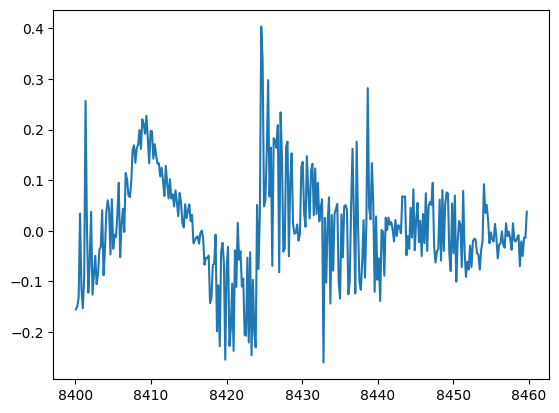

In [89]:
norm = normalize_gp(data, freqs=(8400, 8460))
plt.plot(*norm)

In [94]:
def normalize_gp_smooth(data, freqs=None, inner=10, outer=70):
    if freqs is None:
        freqs = (8400, 8500)
    xs, ys = data
    xs_trimmed = data[0, np.argmin(np.abs(data[0]-freqs[0])):np.argmin(np.abs(data[0]-freqs[1]))]
    normalized_spectrum = []
    for x in tqdm(xs_trimmed):
        i = xs.tolist().index(x)
        x_train = xs[i%4::8]
        y_train = ys[i%4::8]
        mask1 = (x_train > x - outer) & (x_train < x + outer)
        mask2 = ((x_train > x - outer) & (x_train < x - inner)) | ((x_train > x + inner) & (x_train < x + outer))
        kernel = (
            1.0 * RBF(length_scale=50.0) +
            #1.0 * ExpSineSquared(length_scale=50.0, periodicity=20, periodicity_bounds=(1, 40)) + 
            1.0 * WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1))
        )
        x_train1 = x_train[mask1].reshape(-1, 1)
        y_train1 = y_train[mask1]
        gp1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
        gp1.fit(x_train1, y_train1)
        mean1 = gp1.predict(x.reshape(1, -1))[0]

        x_train2 = x_train[mask2].reshape(-1, 1)
        y_train2 = y_train[mask2]
        gp2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
        gp2.fit(x_train2, y_train2)
        mean2 = gp2.predict(x.reshape(1, -1))[0]

        normalized_spectrum.append(mean1 - mean2)
    print(normalized_spectrum)
    return np.array([xs_trimmed, normalized_spectrum])

  8%|▊         | 27/327 [00:34<06:36,  1.32s/it]/opt/conda/envs/hyper/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
  9%|▉         | 31/327 [00:39<06:17,  1.28s/it]/opt/conda/envs/hyper/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
 16%|█▌        | 51/327 [01:05<05:37,  1.22s/it]/opt/conda/envs/hyper/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_

[0.0006022997894810089, 0.021425651024980397, 0.033285073592271175, 0.02953756153598519, 0.04523483366585168, 0.016656424448925122, 0.03527837009774615, 0.051493714146534586, 0.037186742471295275, 0.04106888884761517, 0.038364953613207575, 0.07280685347690152, 0.04367604570580852, 0.04088368001547238, 0.0452713957895341, 0.04156252227155122, 0.04216606190045624, 0.03295814052349044, 0.09274922991486179, 0.09916254824499404, 0.04718106814698686, 0.04365351682634255, 0.0461442198264983, 0.045438646134336125, 0.04777100044751492, 0.04520834071677626, 0.05542189831671962, -0.03848788450305207, 0.050251501455811365, 0.042662051973799464, 0.05653608269982868, 0.09346458519588197, 0.04210174698924618, 0.04205205672070278, 0.04276569717542955, 0.016049690348499013, 0.04635619790186141, 0.04141822154431196, 0.0354026722834746, 0.018182286283010995, 0.019460545238562332, 0.04036598502524669, 0.029702065727789773, 0.017025274173601446, 0.01853908210650701, 0.014781007237424149, 0.0232214306065472

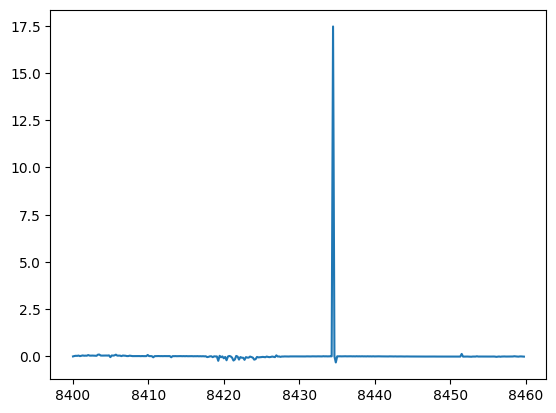

In [95]:
norm = normalize_gp_smooth(data, freqs=(8400, 8460))
plt.plot(*norm)

(-0.1, 0.1)

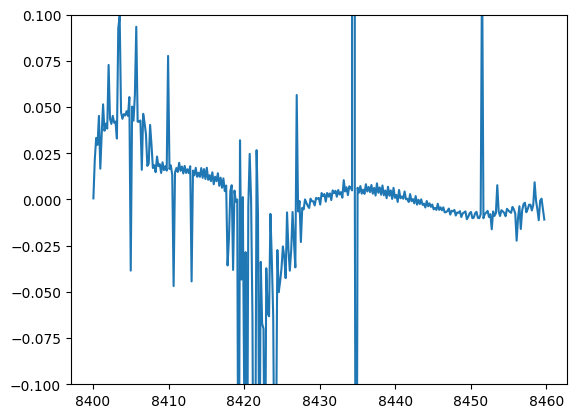

In [96]:
plt.plot(*norm)
plt.ylim(-0.1, 0.1)

In [ ]:
from numpy.polynomial import Polynomial

def normalize_weighted(data, freqs=None, inner=10, outer=70):
    if freqs is None:
        freqs = (8400, 8500)
    xs, ys = data
    freq_diff = xs[1] - xs[0]

    xs_trimmed = data[0, np.argmin(np.abs(data[0]-freqs[0])):np.argmin(np.abs(data[0]-freqs[1]))]
    normalized_spectrum = []
    for x in tqdm(xs_trimmed):
        i = xs.tolist().index(x)

        ind_xs = np.arange(-(outer//2), outer//2+1)

        current_ys = ys[i-outer//2:i+outer//2+1]
        idx = np.isfinite(current_ys)
        
        # Unweighted fit
        unweighted_p = Polynomial.fit(ind_xs[idx], current_ys[idx], 5)
        
        # Weighted fit
        weights = 1 - 0.1*np.exp(-(freq_diff*ind_xs[idx])**2 / (2*inner**2))
        weighted_p = Polynomial.fit(ind_xs[idx], current_ys[idx], 5, w=weights)
        
        unweighted = unweighted_p(0)
        weighted = weighted_p(0)
        #print(f'Unweighted: {unweighted}, Weighted: {weighted}')
        normalized_spectrum.append(unweighted - weighted) #subtract instead of divide
    return np.array([xs_trimmed, normalized_spectrum])

100%|██████████| 327/327 [00:00<00:00, 1007.31it/s]


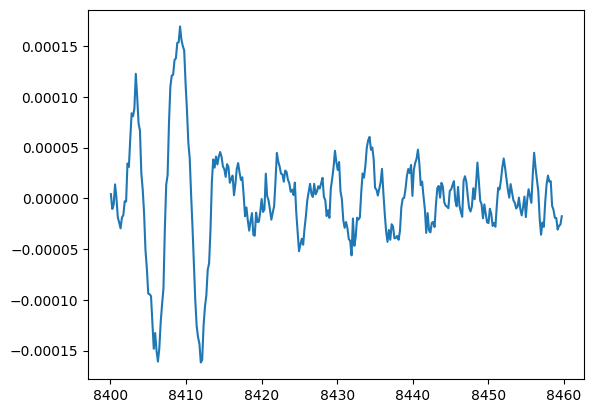

In [101]:
norm2 = normalize_weighted(data, freqs=(8400, 8460))
#plt.plot(*norm)
plt.plot(*norm2)
#plt.ylim(-0.0001, 0.0001)

100%|██████████| 327/327 [00:00<00:00, 1190.99it/s]


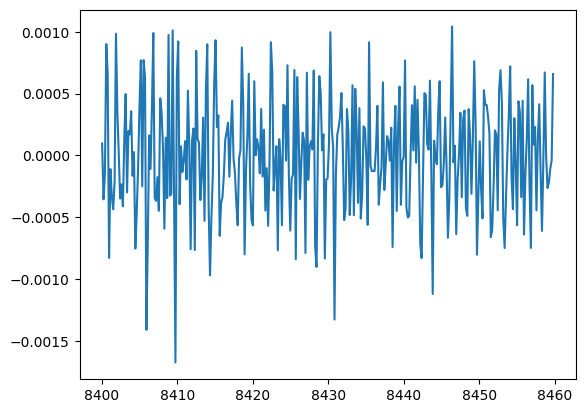

In [161]:
norm3 = normalize_weighted(data, freqs=(8400, 8460), outer=20, inner=0.1)
plt.plot(*norm3)

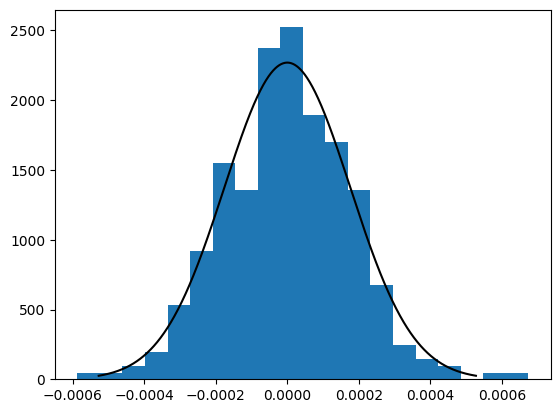

In [144]:
norm_ys = norm3[1]
plt.hist(norm_ys, density=True, bins=20)
mean, std = np.mean(norm_ys), np.std(norm_ys)
x = np.linspace(mean-3*std, mean+3*std, 1000)
p = scipy.stats.norm.pdf(x, mean, std)
plt.plot(x, p, c='k')

In [145]:
data_preprocessed = np.load('/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/0/HIP3.npy')

In [146]:
def normalize_weighted_div(data, freqs=None, inner=10, outer=70):
    if freqs is None:
        freqs = (8400, 8500)
    xs, ys = data
    freq_diff = xs[1] - xs[0]
    for i in range(16, len(ys)-16, 16):  # Excise the 4 unstable valley points in each coarse channel 
        ys[i] = np.nan
        ys[i+15] = np.nan
        ys[i+1] = np.nan
        ys[i+14] = np.nan

    xs_trimmed = data[0, np.argmin(np.abs(data[0]-freqs[0])):np.argmin(np.abs(data[0]-freqs[1]))]
    normalized_spectrum = []
    for x in tqdm(xs_trimmed):
        i = xs.tolist().index(x)

        ind_xs = np.arange(-(outer//2), outer//2+1)

        current_ys = ys[i-outer//2:i+outer//2+1]
        idx = np.isfinite(current_ys)
        
        # Unweighted fit
        unweighted_p = Polynomial.fit(ind_xs[idx], current_ys[idx], 5)
        
        # Weighted fit
        weights = 1 - 0.1*np.exp(-(freq_diff*ind_xs[idx])**2 / (2*inner**2))
        weighted_p = Polynomial.fit(ind_xs[idx], current_ys[idx], 5, w=weights)
        
        unweighted = unweighted_p(0)
        weighted = weighted_p(0)
        #print(f'Unweighted: {unweighted}, Weighted: {weighted}')
        normalized_spectrum.append(unweighted / weighted) #subtract instead of divide
    return np.array([xs_trimmed, normalized_spectrum])

100%|██████████| 327/327 [00:00<00:00, 1165.95it/s]


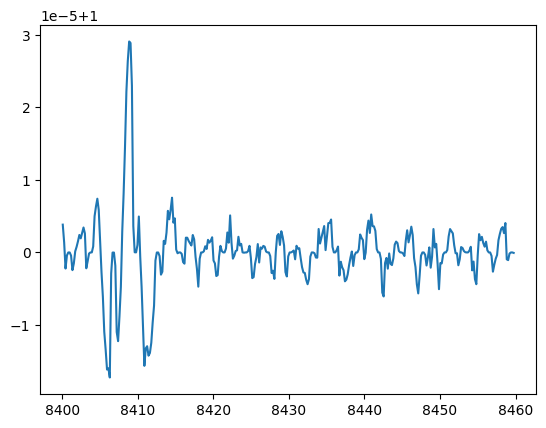

In [149]:
norm_pre = normalize_weighted_div(data_preprocessed, freqs=(8400, 8460), outer=70, inner=0.1)
plt.plot(*norm_pre)

345700.25775884883 373233.27173179574


(342946.95636155416, 375986.5731290904)

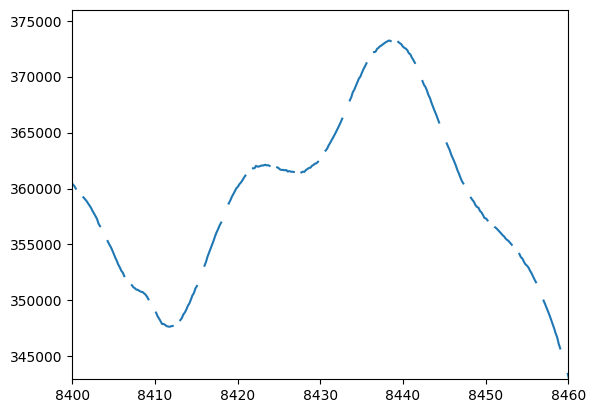

In [126]:
plt.plot(*data_preprocessed)
plt.xlim(8400, 8460)

ys = data_preprocessed[1][np.argmin(np.abs(data_preprocessed[0]-8400)):np.argmin(np.abs(data_preprocessed[0]-8460))]
ymin = np.nanmin(ys)
ymax = np.nanmax(ys)
print(ymin, ymax)
ypad = 0.1 * (ymax - ymin)
plt.ylim(ymin-ypad, ymax+ypad)